## Actividad 3_14
<div style="border-style:groove;border-width:thin;padding:10px">
Debes hacer lo siguiente:
    <ol>
        <li>Soluciona MNIST usando KMeans. Usa X_train y deja X_test e y_test guardados. Recuerda, no tienes que usar las etiquetas para nada.</li>
        <li>Muestra primeras imágenes de la clase 0, 1, 2, 3, 4, etc. ¿Qué tal lo ha hecho?</li>
        <li>Los centroides son datos de 784 valores. Pinta los 10 centroides como si fueran imágenes.</li>
        <li>Piensa como sacar una métrica del resultado.</li>
    </ol>
</div>

In [12]:
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [14]:
X = mnist["data"].to_numpy()
y = mnist["target"].to_numpy().astype(int)
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  y_test: {y_test.shape}")

X_train: (56000, 784)  |  X_test: (14000, 784)  |  y_test: (14000,)


In [16]:
# KMeans con 10 clusters (uno por dígito)
# IMPORTANTE: no usamos y_train en ningún momento del ajuste
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train)

print("KMeans entrenado correctamente.")
print(f"Inercia: {kmeans.inertia_:.0f}")

KMeans entrenado correctamente.
Inercia: 142839744531


In [17]:
# Majority vote: cada cluster recibe el dígito más frecuente entre sus miembros
cluster_to_digit = np.zeros(10, dtype=int)
for c in range(10):
    mask = kmeans.labels_ == c
    if mask.sum() > 0:
        cluster_to_digit[c] = np.bincount(y_train[mask]).argmax()

print("Mapa cluster → dígito:", cluster_to_digit)

Mapa cluster → dígito: [1 6 4 8 6 1 0 7 2 3]


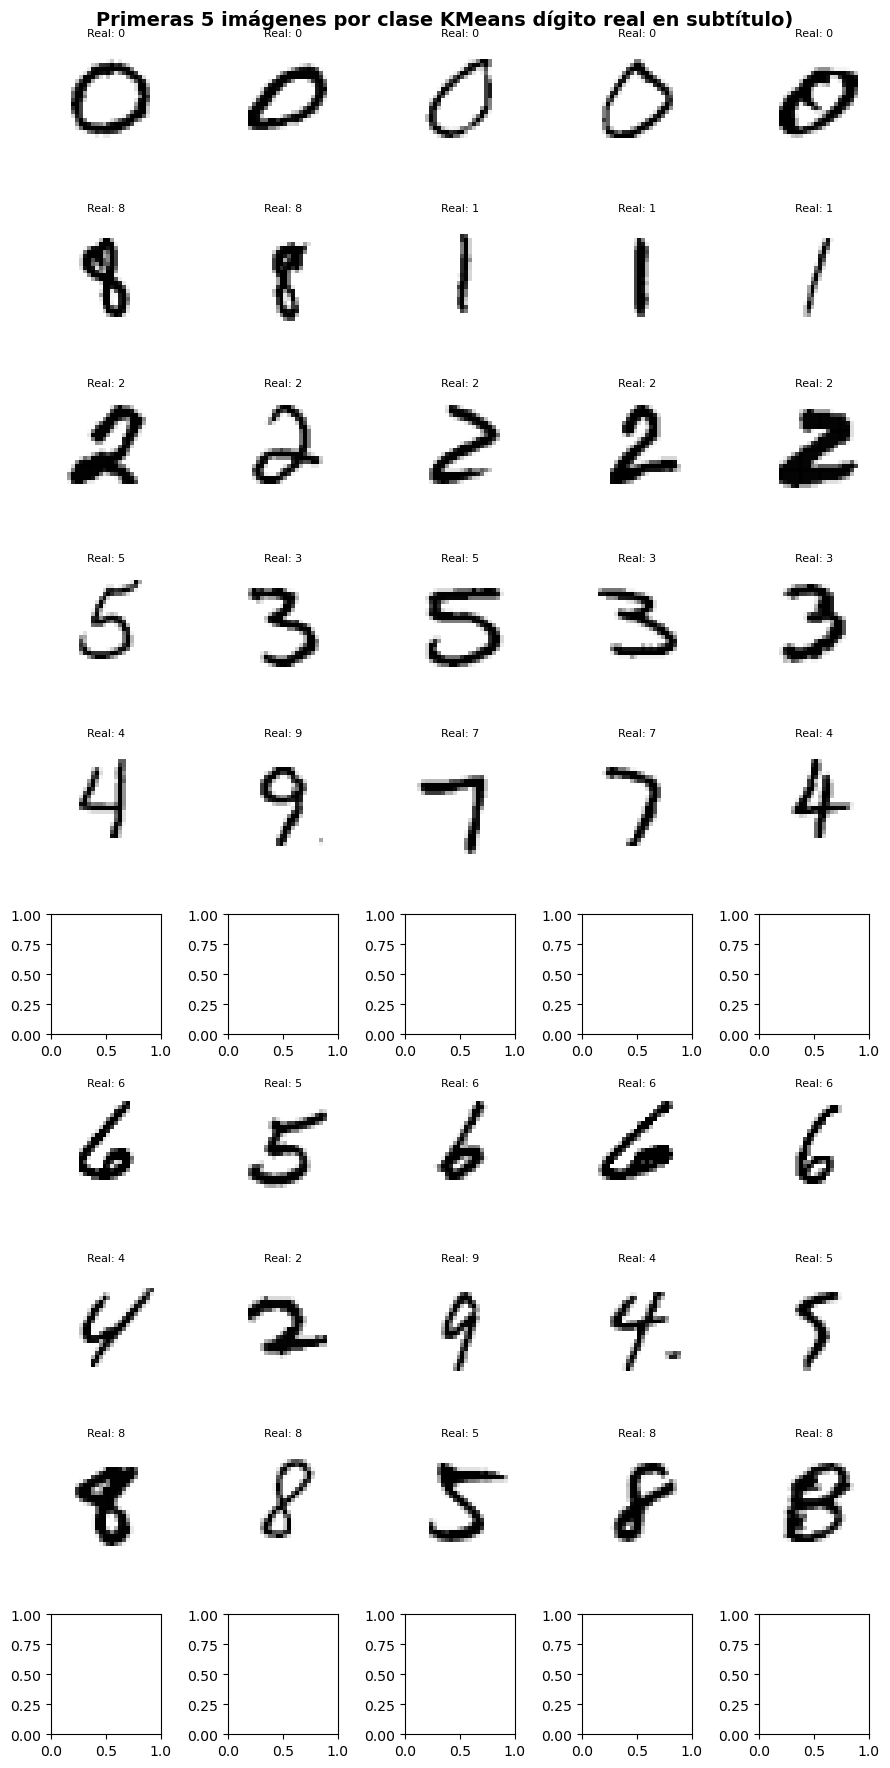

In [19]:
fig, axes = plt.subplots(10, 5, figsize=(9, 18))
fig.suptitle("Primeras 5 imágenes por clase KMeans dígito real en subtítulo)",
             fontsize=14, fontweight='bold')

for digit in range(10):
    clusters_for_digit = np.where(cluster_to_digit == digit)[0]
    if len(clusters_for_digit) == 0:
        continue
    cluster_id = clusters_for_digit[0]
    indices = np.where(kmeans.labels_ == cluster_id)[0][:5]

    for j, idx in enumerate(indices):
        ax = axes[digit, j]
        ax.imshow(X_train[idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"Real: {y_train[idx]}", fontsize=8)
        ax.axis('off')
    axes[digit, 0].set_ylabel(f"Clase→{digit}", fontsize=9)

plt.tight_layout()
plt.show()

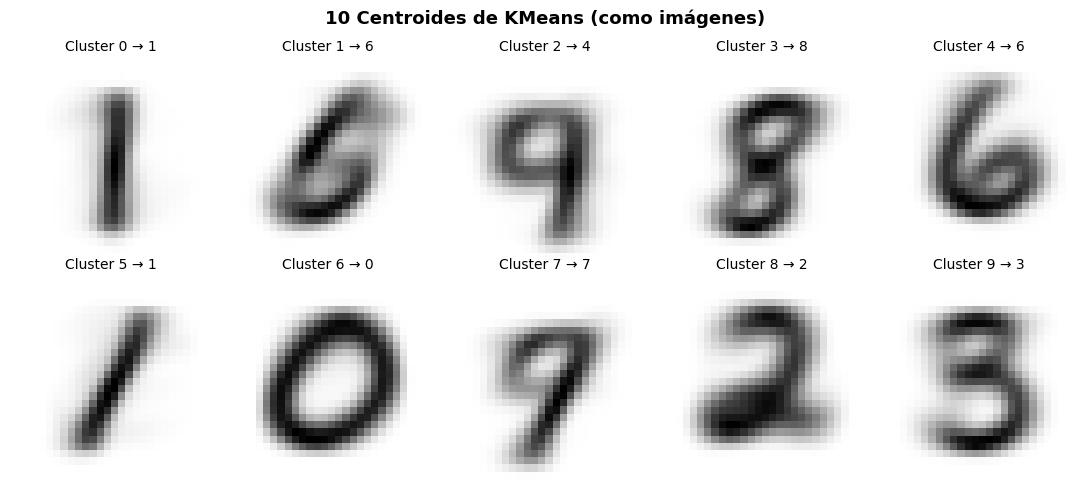

Los centroides son el 'dígito promedio' aprendido por KMeans para cada cluster.


In [21]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle("10 Centroides de KMeans (como imágenes)", fontsize=13, fontweight='bold')

for c in range(10):
    ax = axes[c // 5, c % 5]
    centroid = kmeans.cluster_centers_[c].reshape(28, 28)  # 64 valores → imagen 8x8
    ax.imshow(centroid, cmap='gray_r')
    ax.set_title(f"Cluster {c} → {cluster_to_digit[c]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Los centroides son el 'dígito promedio' aprendido por KMeans para cada cluster.")

Accuracy en test set: 58.39%
Inercia KMeans:       142839744531


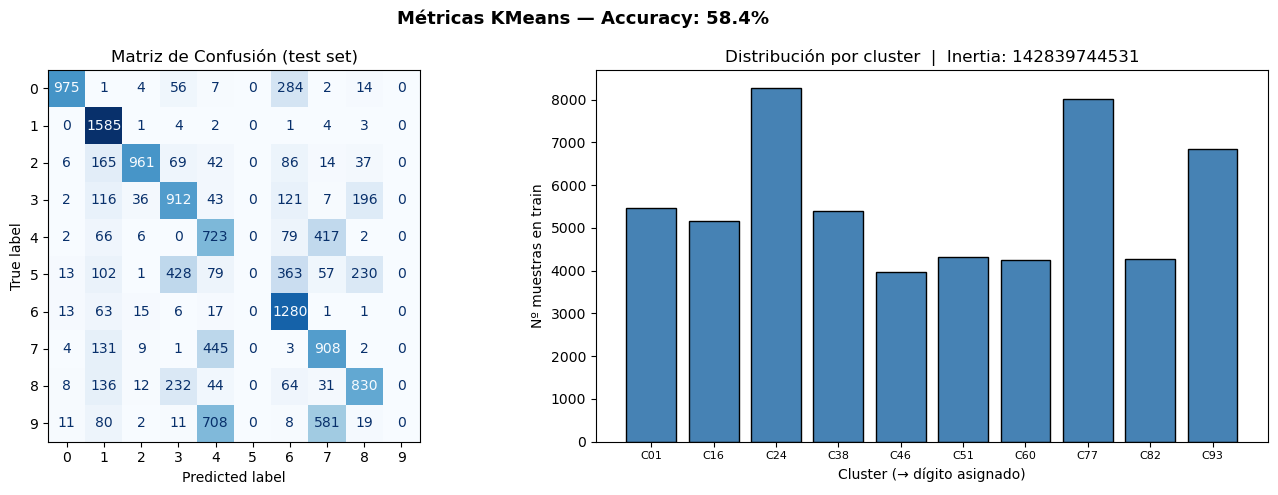

In [22]:
# Predicción en test set (sin usar y_test en el ajuste)
y_pred = cluster_to_digit[kmeans.predict(X_test)]
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en test set: {acc*100:.2f}%")
print(f"Inercia KMeans:       {kmeans.inertia_:.0f}")

# Visualización de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Métricas KMeans — Accuracy: {acc*100:.1f}%", fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Matriz de Confusión (test set)")

cluster_sizes = np.bincount(kmeans.labels_, minlength=10)
axes[1].bar(range(10), cluster_sizes, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f"C{i}{cluster_to_digit[i]}" for i in range(10)], fontsize=8)
axes[1].set_xlabel("Cluster (→ dígito asignado)")
axes[1].set_ylabel("Nº muestras en train")
axes[1].set_title(f"Distribución por cluster  |  Inertia: {kmeans.inertia_:.0f}")

plt.tight_layout()
plt.show()